# 1、数据的存储

举例1：从TXT文档中加载数据，向量化后存储到Chroma数据库

In [6]:
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_ollama import OllamaEmbeddings
import os
import dotenv

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 步骤1：创建一个TextLoader的实例，并将指定的文档加载
loader = TextLoader(
    file_path="./asset/load/09-ai1.txt",
    encoding="utf-8",
)

docs = loader.load()


# 步骤2：创建文本拆分器，并拆分文档
text_splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)

splitter_docs = text_splitter.split_documents(docs)

# print(len(splitter_docs))

# 步骤3：创建嵌入模型
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

# 步骤4：将文档及嵌入模型传入到Chroma相关的结构中，进行数据的存储
db = Chroma.from_documents(
    documents=splitter_docs,
    embedding=embedding_model,
)

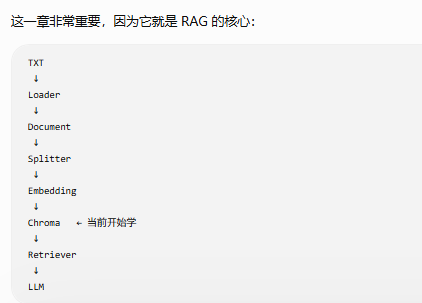

1、当前的数据到底存在哪里了？

如果我们使用的from_documents()中没有显式的指明存储位置的话，则将当前的数据存储在内存中，并缓存起来。
如果需要指明具体的存储位置，需要设置参数persist_directory的值。

In [8]:
db1 = Chroma.from_documents(
    documents=splitter_docs,
    embedding=embedding_model,
    persist_directory="./asset/chroma-1",
)

2、需要明确，在向量数据库中，不仅存储了数据（或文档）的向量，而且还存储了数据（或文档）本身。

演示一下：检索的需求

In [12]:
query = "人工智能的核心技术有哪些呢？"

docs = db1.similarity_search(query)

print(docs[0].page_content)

人工智能综述：发展、应用与未来展望

摘要
人工智能（Artificial Intelligence，AI）作为计算机科学的一个重要分支，近年来取得了突飞猛进的发展。本文综述了人工智能的发展历程、核心技术、应用领域以及未来发展趋势。通过对人工智能的定义、历史背景、主要技术（如机器学习、深度学习、自然语言处理等）的详细介绍，探讨了人工智能在医疗、金融、教育、交通等领域的应用，并分析了人工智能发展过程中面临的挑战与机遇。最后，本文对人工智能的未来发展进行了展望，提出了可能的突破方向。

1. 引言
人工智能是指通过计算机程序模拟人类智能的一门科学。自20世纪50年代诞生以来，人工智能经历了多次起伏，近年来随着计算能力的提升和大数据的普及，人工智能技术取得了显著的进展。人工智能的应用已经渗透到日常生活的方方面面，从智能手机的语音助手到自动驾驶汽车，从医疗诊断到金融分析，人工智能正在改变着人类社会的运行方式。

2. 人工智能的发展历程
2.1 早期发展
人工智能的概念最早可以追溯到20世纪50年代。1956年，达特茅斯会议（Dartmouth Conference）被认为是人工智能研究的正式开端。在随后的几十年里，人工智能研究经历了多次高潮与低谷。早期的研究主要集中在符号逻辑和专家系统上，但由于计算能力的限制和算法的不足，进展缓慢。
2.2 机器学习的兴起
20世纪90年代，随着统计学习方法的引入，机器学习逐渐成为人工智能研究的主流。支持向量机（SVM）、决策树、随机森林等算法在分类和回归任务中取得了良好的效果。这一时期，机器学习开始应用于数据挖掘、模式识别等领域。
2.3 深度学习的突破
2012年，深度学习在图像识别领域取得了突破性进展，标志着人工智能进入了一个新的阶段。深度学习通过多层神经网络模拟人脑的工作方式，能够自动提取特征并进行复杂的模式识别。卷积神经网络（CNN）、循环神经网络（RNN）和长短期记忆网络（LSTM）等深度学习模型在图像处理、自然语言处理、语音识别等领域取得了显著成果。

3. 人工智能的核心技术
3.1 机器学习
机器学习是人工智能的核心技术之一，通过算法使计算机从数据中学习并做出决策。常见的机器学习算法包括监督学习、无监督学习和强化学习。监督学习通过标记数据进行训练，无监督学习则从未标记数据中寻找模式，强化学习则通过与环境交互来优化决策。


举例2：操作csv文档，并向量化

In [15]:
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.document_loaders import CSVLoader
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

import os
import dotenv

dotenv.load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 获取嵌入模型
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# 加载文档并拆分（第1次拆分）
loader = CSVLoader("./asset/load/03-load.csv", encoding='utf-8')
pages = loader.load_and_split()
#print(len(pages))  # 4

# 文本拆分（第2次拆分）
text_spliter = CharacterTextSplitter.from_tiktoken_encoder(chunk_size=500)
docs = text_spliter.split_documents(pages)

# 向量存储
db_path = './asset/chroma-2'
db = Chroma.from_documents(docs, embeddings, persist_directory=db_path)

# 2、数据的检索

前置代码：

In [18]:
# 1.导入相关依赖
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings

# 2.定义文档
raw_documents = [
    Document(
        page_content="葡萄是一种常见的水果，属于葡萄科葡萄属植物。它的果实呈圆形或椭圆形，颜色有绿色、紫色、红色等多种。葡萄富含维生素C和抗氧化物质，可以直接食用或酿造成葡萄酒。",
        metadata={"source": "水果", "type": "植物"}
    ),
    Document(
        page_content="白菜是十字花科蔬菜，原产于中国北方。它的叶片层层包裹形成紧密的球状，口感清脆微甜。白菜富含膳食纤维和维生素K，常用于制作泡菜、炒菜或煮汤。",
        metadata={"source": "蔬菜", "type": "植物"}
    ),
    Document(
        page_content="狗是人类最早驯化的动物之一，属于犬科。它们具有高度社会性，能理解人类情绪，常被用作宠物、导盲犬或警犬。不同品种的狗在体型、毛色和性格上有很大差异。",
        metadata={"source": "动物", "type": "哺乳动物"}
    ),
    Document(
        page_content="猫是小型肉食性哺乳动物，性格独立但也能与人类建立亲密关系。它们夜视能力极强，擅长捕猎老鼠。家猫的品种包括波斯猫、暹罗猫等，毛色和花纹多样。",
        metadata={"source": "动物", "type": "哺乳动物"}
    ),
    Document(
        page_content="人类是地球上最具智慧的生物，属于灵长目人科。现代人类（智人）拥有高度发达的大脑，创造了语言、工具和文明。人类的平均寿命约70-80年，分布在全球各地。",
        metadata={"source": "生物", "type": "灵长类"}
    ),
    Document(
        page_content="太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。",
        metadata={"source": "天文", "type": "恒星"}
    ),
    Document(
        page_content="长城是中国古代的军事防御工程，总长度超过2万公里。它始建于春秋战国时期，秦朝连接各段，明朝大规模重修。长城是世界文化遗产和人类建筑奇迹。",
        metadata={"source": "历史", "type": "建筑"}
    ),
    Document(
        page_content="量子力学是研究微观粒子运动规律的物理学分支。它提出了波粒二象性、测不准原理等概念，彻底改变了人类对物质世界的认知。量子计算机正是基于这一理论发展而来。",
        metadata={"source": "物理", "type": "科学"}
    ),
    Document(
        page_content="《红楼梦》是中国古典文学四大名著之一，作者曹雪芹。小说以贾、史、王、薛四大家族的兴衰为背景，描绘了贾宝玉与林黛玉的爱情悲剧，反映了封建社会的种种矛盾。",
        metadata={"source": "文学", "type": "小说"}
    ),
    Document(
        page_content="新冠病毒（SARS-CoV-2）是一种可引起呼吸道疾病的冠状病毒。它通过飞沫传播，主要症状包括发热、咳嗽、乏力。疫苗和戴口罩是有效的预防措施。",
        metadata={"source": "医学", "type": "病毒"}
    )
]
# 3. 创建嵌入模型
embedding = OllamaEmbeddings(model="nomic-embed-text")

# 4.创建向量数据库
db = Chroma.from_documents(
    documents=raw_documents,
    embedding=embedding,
    persist_directory="./asset/chroma-3",
)

① 相似性检索（similarity_search）

In [19]:
# 5. 检索示例（返回前3个最相关结果）
query = "哺乳动物"
docs = db.similarity_search(query, k=3)  # k=3表示返回3个最相关文档
print(f"查询: '{query}' 的结果:")
for i, doc in enumerate(docs, 1):
    print(f"\n结果 {i}:")
    print(f"内容: {doc.page_content}")
    print(f"元数据: {doc.metadata}")

查询: '哺乳动物' 的结果:

结果 1:
内容: 白菜是十字花科蔬菜，原产于中国北方。它的叶片层层包裹形成紧密的球状，口感清脆微甜。白菜富含膳食纤维和维生素K，常用于制作泡菜、炒菜或煮汤。
元数据: {'source': '蔬菜', 'type': '植物'}

结果 2:
内容: 葡萄是一种常见的水果，属于葡萄科葡萄属植物。它的果实呈圆形或椭圆形，颜色有绿色、紫色、红色等多种。葡萄富含维生素C和抗氧化物质，可以直接食用或酿造成葡萄酒。
元数据: {'source': '水果', 'type': '植物'}

结果 3:
内容: 太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。
元数据: {'source': '天文', 'type': '恒星'}


② 支持直接对问题向量查询（similarity_search_by_vector）

In [20]:
query = "哺乳动物"
embedding_vector = embedding.embed_query(query)

docs = db.similarity_search_by_vector(embedding_vector, k=3)

print(f"查询: '{query}' 的结果:")
for i, doc in enumerate(docs, 1):
    print(f"\n结果 {i}:")
    print(f"内容: {doc.page_content}")
    print(f"元数据: {doc.metadata}")

查询: '哺乳动物' 的结果:

结果 1:
内容: 白菜是十字花科蔬菜，原产于中国北方。它的叶片层层包裹形成紧密的球状，口感清脆微甜。白菜富含膳食纤维和维生素K，常用于制作泡菜、炒菜或煮汤。
元数据: {'source': '蔬菜', 'type': '植物'}

结果 2:
内容: 葡萄是一种常见的水果，属于葡萄科葡萄属植物。它的果实呈圆形或椭圆形，颜色有绿色、紫色、红色等多种。葡萄富含维生素C和抗氧化物质，可以直接食用或酿造成葡萄酒。
元数据: {'source': '水果', 'type': '植物'}

结果 3:
内容: 太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。
元数据: {'source': '天文', 'type': '恒星'}


③ 相似性检索，支持过滤元数据（filter）

In [22]:
query = "哺乳动物"

docs = db.similarity_search(
    query=query,
    k=3,
    filter={"source": "动物"})

for i, doc in enumerate(docs, 1):
    print(f"\n结果 {i}:")
    print(f"内容: {doc.page_content}")
    print(f"元数据: {doc.metadata}")


④ 通过L2距离分数进行搜索（similarity_search_with_score）

In [23]:
docs = db.similarity_search_with_score(
    "量子力学是什么?"
)
for doc, score in docs:
    print(f" [L2距离得分={score:.3f}] {doc.page_content} [{doc.metadata}]")

 [L2距离得分=0.000] 太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。 [{'source': '天文', 'type': '恒星'}]
 [L2距离得分=1.000] 新冠病毒（SARS-CoV-2）是一种可引起呼吸道疾病的冠状病毒。它通过飞沫传播，主要症状包括发热、咳嗽、乏力。疫苗和戴口罩是有效的预防措施。 [{'source': '医学', 'type': '病毒'}]
 [L2距离得分=2.000] 长城是中国古代的军事防御工程，总长度超过2万公里。它始建于春秋战国时期，秦朝连接各段，明朝大规模重修。长城是世界文化遗产和人类建筑奇迹。 [{'source': '历史', 'type': '建筑'}]
 [L2距离得分=3.000] 量子力学是研究微观粒子运动规律的物理学分支。它提出了波粒二象性、测不准原理等概念，彻底改变了人类对物质世界的认知。量子计算机正是基于这一理论发展而来。 [{'source': '物理', 'type': '科学'}]


说明：分数值越小，检索到的文档越和问题相似。分值取值范围：[0，正无穷]

⑤ 通过余弦相似度分数进行搜索（_similarity_search_with_relevance_scores）

In [24]:
docs = db._similarity_search_with_relevance_scores(
    "量子力学是什么?"
)
for doc, score in docs:
    print(f"* [余弦相似度得分={score:.3f}] {doc.page_content} [{doc.metadata}]")

* [余弦相似度得分=1.000] 太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。 [{'source': '天文', 'type': '恒星'}]
* [余弦相似度得分=0.500] 新冠病毒（SARS-CoV-2）是一种可引起呼吸道疾病的冠状病毒。它通过飞沫传播，主要症状包括发热、咳嗽、乏力。疫苗和戴口罩是有效的预防措施。 [{'source': '医学', 'type': '病毒'}]
* [余弦相似度得分=0.333] 长城是中国古代的军事防御工程，总长度超过2万公里。它始建于春秋战国时期，秦朝连接各段，明朝大规模重修。长城是世界文化遗产和人类建筑奇迹。 [{'source': '历史', 'type': '建筑'}]
* [余弦相似度得分=0.250] 量子力学是研究微观粒子运动规律的物理学分支。它提出了波粒二象性、测不准原理等概念，彻底改变了人类对物质世界的认知。量子计算机正是基于这一理论发展而来。 [{'source': '物理', 'type': '科学'}]


说明：分数值越接近1（上限），检索到的文档越和问题相似。

⑥ MMR（最大边际相关性，max_marginal_relevance_search）

MMR 是一种平衡`相关性` 和`多样性`的检索策略，避免返回高度相似的冗余结果。

In [25]:
docs = db.max_marginal_relevance_search(
    query="量子力学是什么",
    lambda_mult=0.8,  # 侧重相似性
)

print("🔍 关于【量子力学是什么】的搜索结果：")
print("=" * 50)
for i, doc in enumerate(docs):
    print(f"\n📖 结果 {i+1}:")
    print(f"📌 内容: {doc.page_content}")
    print(f"🏷️ 标签: {', '.join(f'{k}={v}' for k, v in doc.metadata.items())}")

🔍 关于【量子力学是什么】的搜索结果：

📖 结果 1:
📌 内容: 狗是人类最早驯化的动物之一，属于犬科。它们具有高度社会性，能理解人类情绪，常被用作宠物、导盲犬或警犬。不同品种的狗在体型、毛色和性格上有很大差异。
🏷️ 标签: source=动物, type=哺乳动物

📖 结果 2:
📌 内容: 太阳是太阳系的中心恒星，直径约139万公里，主要由氢和氦组成。它通过核聚变反应产生能量，为地球提供光和热。太阳活动周期约为11年，会影响地球气候。
🏷️ 标签: source=天文, type=恒星

📖 结果 3:
📌 内容: 长城是中国古代的军事防御工程，总长度超过2万公里。它始建于春秋战国时期，秦朝连接各段，明朝大规模重修。长城是世界文化遗产和人类建筑奇迹。
🏷️ 标签: source=历史, type=建筑

📖 结果 4:
📌 内容: 量子力学是研究微观粒子运动规律的物理学分支。它提出了波粒二象性、测不准原理等概念，彻底改变了人类对物质世界的认知。量子计算机正是基于这一理论发展而来。
🏷️ 标签: source=物理, type=科学


参数说明：`lambda_mult`参数值介于 0 到 1 之间，用于确定结果之间的多样性程度，其中 0 对应最大多样性，1 对应最小多样性。默认值为 0.5。

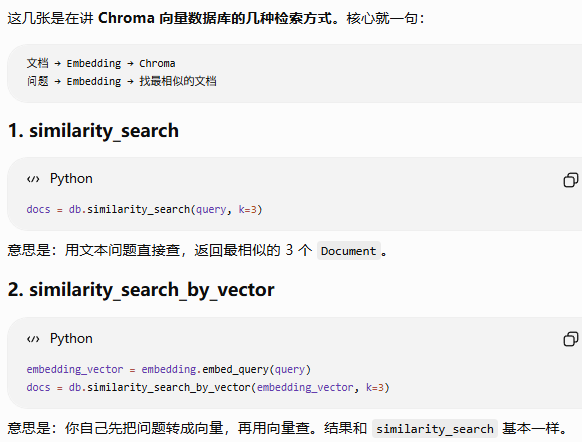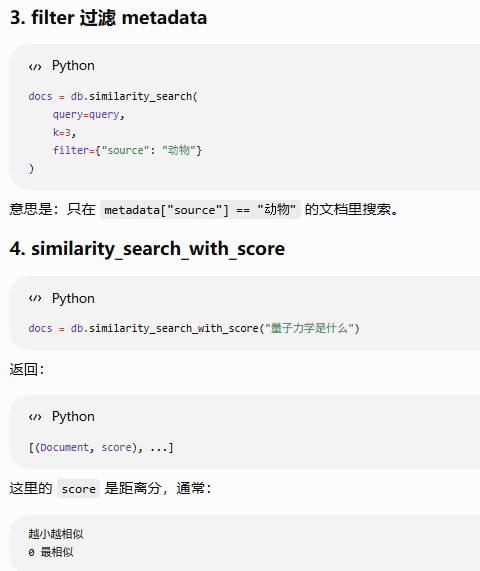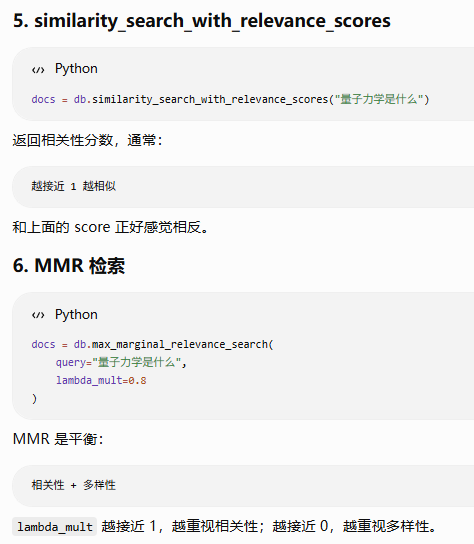

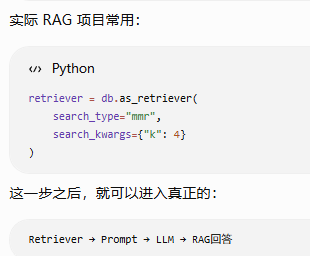